In [1]:
import torch
from data_provider.data_factory import data_provider_baseline

In [2]:
data_root_path = "./dataset/"

In [3]:
# 创建简单的配置对象用于测试
class Args:
    def __init__(self):
        self.data = 'Dataset_original'
        self.root_path = "./dataset/"  # 使用定义的路径
        self.dataset = 'exp'
        self.batch_size = 32
        self.num_workers = 0
        self.charge_discharge_length = 100
        self.early_cycle_threshold = 100
        self.seq_len = 5
        self.pred_len = 5
        self.use_multi_gpu = False
        self.devices = '0'
        self.weighted_loss = False  # 添加缺失的属性
        
args = Args()


# 测试 `Dataset_original`

In [4]:

# 加载数据
print("正在加载训练数据...")
train_data, train_loader = data_provider_baseline(args, 'train')
print(f"✓ 训练数据加载完成！")
print(f"  数据集大小: {len(train_data)}")
print(f"  批次数量: {len(train_loader)}")

正在加载训练数据...


100%|██████████| 3/3 [00:02<00:00,  1.17it/s]

✓ 训练数据加载完成！
  数据集大小: 288
  批次数量: 9


In [5]:
# 获取一个批次的数据并查看形状
print("\n=== 批次数据形状信息 ===")
batch = next(iter(train_loader))

# 检查批次是字典还是元组
if isinstance(batch, dict):
    print("批次数据是字典类型")
    for key, value in batch.items():
        if torch.is_tensor(value):
            print(f"  {key}:")
            print(f"    - shape: {value.shape}")
            print(f"    - dtype: {value.dtype}")
            print(f"    - min: {value.min():.4f}, max: {value.max():.4f}, mean: {value.mean():.4f}")
        else:
            print(f"  {key}: type = {type(value)}")
elif isinstance(batch, (tuple, list)):
    print(f"批次数据是 {type(batch).__name__} 类型，包含 {len(batch)} 个元素")
    for i, value in enumerate(batch):
        if torch.is_tensor(value):
            print(f"  元素 [{i}]:")
            print(f"    - shape: {value.shape}")
            print(f"    - dtype: {value.dtype}")
            if value.numel() > 0:
                print(f"    - min: {value.min():.4f}, max: {value.max():.4f}, mean: {value.mean():.4f}")
        else:
            print(f"  元素 [{i}]: type = {type(value)}")
else:
    print(f"批次数据类型: {type(batch)}")


=== 批次数据形状信息 ===
批次数据是 tuple 类型，包含 7 个元素
  元素 [0]:
    - shape: torch.Size([32, 100, 3, 100])
    - dtype: torch.float32
    - min: -0.7504, max: 1.1108, mean: 0.2713
  元素 [1]:
    - shape: torch.Size([32, 100])
    - dtype: torch.float32
    - min: 0.0000, max: 1.0000, mean: 0.5719
  元素 [2]:
    - shape: torch.Size([32, 1])
    - dtype: torch.float32
    - min: -1.1250, max: 1.3046, mean: -0.1167
  元素 [3]:
    - shape: torch.Size([32])
    - dtype: torch.float32
    - min: 2.0000, max: 2.0000, mean: 2.0000
  元素 [4]:
    - shape: torch.Size([32])
    - dtype: torch.float32
    - min: 1.0000, max: 1.0000, mean: 1.0000
  元素 [5]:
    - shape: torch.Size([32])
    - dtype: torch.float32
    - min: 1.0000, max: 1.0000, mean: 1.0000
  元素 [6]:
    - shape: torch.Size([32])
    - dtype: torch.float32
    - min: 1.0000, max: 1.0000, mean: 1.0000


In [6]:
# 查看单个样本的详细信息
print("\n=== 单个样本详细信息 ===")
first_sample = train_data[0]

if isinstance(first_sample, dict):
    print("样本数据是字典类型")
    for key, value in first_sample.items():
        if torch.is_tensor(value):
            print(f"  {key}:")
            print(f"    - shape: {value.shape}")
            print(f"    - dtype: {value.dtype}")
            if value.numel() > 0:
                print(f"    - min: {value.min():.4f}, max: {value.max():.4f}, mean: {value.mean():.4f}")
        else:
            print(f"  {key}: {value}")
elif isinstance(first_sample, (tuple, list)):
    print(f"样本数据是 {type(first_sample).__name__} 类型，包含 {len(first_sample)} 个元素")
    for i, value in enumerate(first_sample):
        if torch.is_tensor(value):
            print(f"  元素 [{i}]:")
            print(f"    - shape: {value.shape}")
            print(f"    - dtype: {value.dtype}")
            if value.numel() > 0:
                print(f"    - min: {value.min():.4f}, max: {value.max():.4f}, mean: {value.mean():.4f}")
        else:
            print(f"  元素 [{i}]: {value}")
else:
    print(f"样本数据类型: {type(first_sample)}")


=== 单个样本详细信息 ===
样本数据是字典类型
  cycle_curve_data:
    - shape: torch.Size([100, 3, 100])
    - dtype: torch.float32
    - min: -0.7504, max: 1.0866, mean: 0.4730
  curve_attn_mask:
    - shape: torch.Size([100])
    - dtype: torch.float32
    - min: 0.0000, max: 1.0000, mean: 0.0500
  labels: [1.30464646]
  life_class: 2
  scaled_life_class: 1
  weight: 1.0
  dataset_id: 9
  cj_cycle_curve_data:
    - shape: torch.Size([100, 3, 100])
    - dtype: torch.float64
    - min: -0.7951, max: 1.0866, mean: 0.4730
  seen_unseen_id: 1


In [12]:
# 打印dataset_id
for sample in train_data:
    if isinstance(sample, dict) and 'dataset_id' in sample:
        print("\n=== dataset_id 信息 ===")
        print(f"dataset_id shape: {sample['dataset_id']}")


=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== dataset_id 信息 ===
dataset_id shape: 9

=== datase

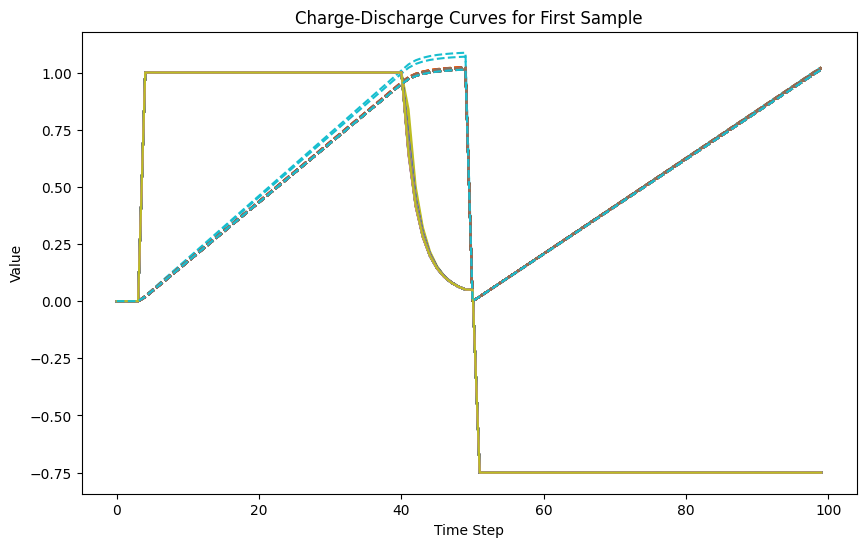

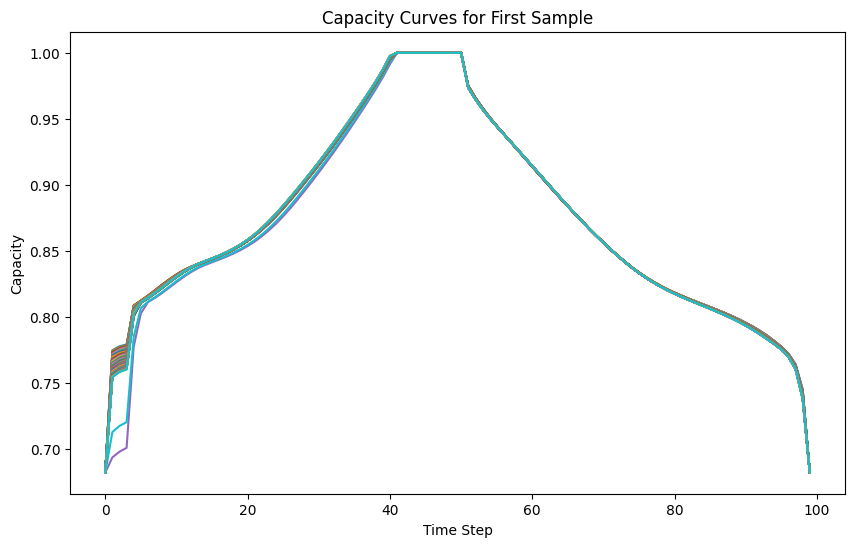

In [12]:
# 画出第一个样本的充放电曲线
import matplotlib.pyplot as plt
cycle_curve = first_sample['cycle_curve_data'].numpy() # [100, 3, 100] capacity, Voltage, Current

# 电压电流曲线
plt.figure(figsize=(10, 6))
for i in range(cycle_curve.shape[0]):
    voltage = cycle_curve[i, 1, :]
    current = cycle_curve[i, 2, :]
    plt.plot(voltage, label=f'Cycle {i+1} Voltage')
    plt.plot(current, label=f'Cycle {i+1} Current', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Charge-Discharge Curves for First Sample')
plt.show()

# 容量曲线
plt.figure(figsize=(10, 6))
for i in range(cycle_curve.shape[0]):
    capacity = cycle_curve[i, 0, :]
    plt.plot(capacity, label=f'Cycle {i+1} Capacity')
plt.xlabel('Time Step')
plt.ylabel('Capacity')
plt.title('Capacity Curves for First Sample')
plt.show()


In [6]:
# 测试其他数据集拆分 (验证集和测试集)
print("\n=== 验证集和测试集信息 ===")

try:
    val_data, val_loader = data_provider_baseline(args, 'val')
    print(f"✓ 验证集加载完成")
    print(f"  数据集大小: {len(val_data)}")
    print(f"  批次数量: {len(val_loader)}")
except Exception as e:
    print(f"✗ 验证集加载失败: {e}")

try:
    test_data, test_loader = data_provider_baseline(args, 'test')
    print(f"✓ 测试集加载完成")
    print(f"  数据集大小: {len(test_data)}")
    print(f"  批次数量: {len(test_loader)}")
except Exception as e:
    print(f"✗ 测试集加载失败: {e}")


=== 验证集和测试集信息 ===


100%|██████████| 4/4 [00:01<00:00,  2.57it/s]


✗ 验证集加载失败: 


100%|██████████| 4/4 [00:02<00:00,  1.79it/s]

✗ 测试集加载失败: 


## 数据形状总结

### 训练数据集
- **数据集大小**: 4,512 个样本
- **批次数量**: 141 个批次（batch_size=32）

### 批次数据结构（Tuple，7个元素）
1. **充放电曲线数据**: `[32, 100, 3, 100]`
   - 32: batch size
   - 100: 循环数量（cycles）
   - 3: 3种曲线类型（充电/放电/其他）
   - 100: 每条曲线的数据点数
   - 数据范围: [-5.0, 5.0]

2. **曲线注意力掩码**: `[32, 100]`
   - 用于指示哪些循环是有效的
   - 值为 0 或 1

3. **标签（寿命预测）**: `[32, 1]`
   - 归一化后的电池寿命标签
   - 数据范围: [-1.5, 1.8]

4. **寿命类别**: `[32]`
   - 原始寿命分类标签
   - 值范围: [3, 4]

5. **缩放后的寿命类别**: `[32]`
   - 缩放后的分类标签
   - 值范围: [2, 3]

6. **样本权重**: `[32]`
   - 用于加权损失
   - 当前全为 1.0

7. **数据集ID**: `[32]`
   - 标识样本来源数据集
   - 当前全为 1.0

### 单个样本结构（Dictionary）
- `cycle_curve_data`: `[100, 3, 100]` - 充放电曲线数据
- `curve_attn_mask`: `[100]` - 注意力掩码
- `labels`: 标量 - 寿命标签
- `life_class`: 标量 - 寿命类别
- `scaled_life_class`: 标量 - 缩放后的类别
- `weight`: 标量 - 样本权重
- `dataset_id`: 标量 - 数据集ID
- `cj_cycle_curve_data`: `[100, 3, 100]` - 数据增强后的曲线
- `seen_unseen_id`: 标量 - 见过/未见过标识

# 测试 `Dataset_AE`

In [1]:
from data_provider.data_loader import Dataset_AE, collate_fn_AE
from torch.utils.data import DataLoader

In [7]:
import numpy as np
a =np.zeros(5)
a[:3] = 1
print(a)
a[3:] = 2
print(a)

[1. 1. 1. 0. 0.]
[1. 1. 1. 2. 2.]


In [3]:
# 创建简单的配置对象用于测试
class Args:
    def __init__(self):
        self.data = 'Dataset_original'
        self.root_path = "./dataset/"  # 使用定义的路径
        self.dataset = 'exp'
        self.batch_size = 32
        self.num_workers = 0
        self.charge_discharge_length = 100
        self.early_cycle_threshold = 100
        self.seq_len = 5
        self.pred_len = 5
        self.use_multi_gpu = False
        self.devices = '0'
        self.weighted_loss = False  # 添加缺失的属性
        
args = Args()


In [4]:
# 示例 1: 不使用 padding
dataset_no_pad = Dataset_AE(
    args=args,
    flag='train',
    soh_len=None,
    padding_mode='zero'  # 此时 padding_mode 参数无效
)

# 示例 2: 使用零填充
dataset_zero_pad = Dataset_AE(
    args=args,
    flag='train',
    soh_len=2000,  # 统一填充到 2000 个循环
    padding_mode='zero'
)

# 示例 3: 使用最后值填充
dataset_last_pad = Dataset_AE(
    args=args,
    flag='train',
    soh_len=2000,
    padding_mode='last'
)

# 创建 DataLoader
dataloader = DataLoader(
    dataset_zero_pad,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn_AE
)

# 使用
for batch in dataloader:
    discharge_seqs = batch['discharge_capacity_seq']  # [B, soh_len]
    seq_lengths = batch['seq_length']  # [B], 每个样本的真实 EOL
    eols = batch['eol']  # [B], 与 seq_length 相同

Loading train data for AE: 100%|██████████| 3/3 [00:01<00:00,  2.16it/s]


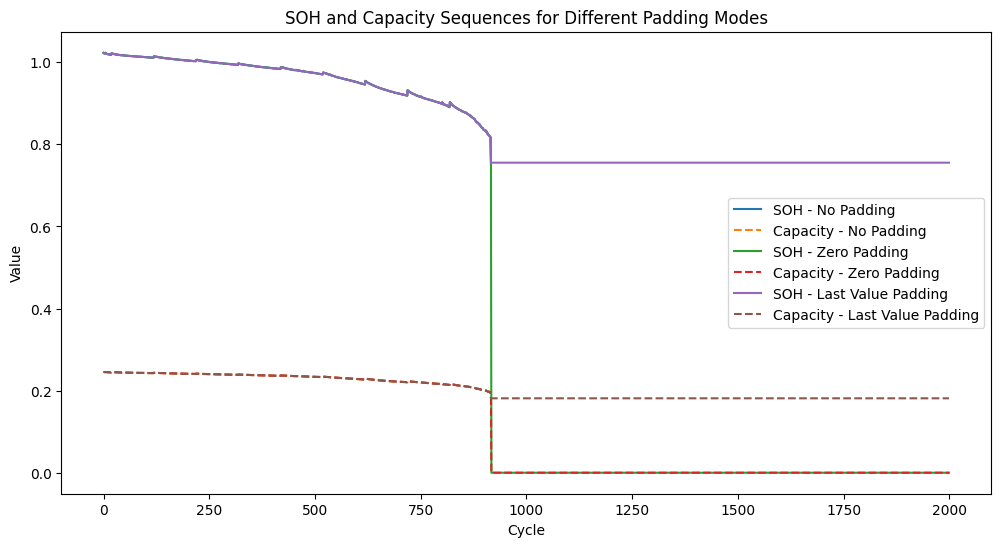

In [6]:
# 画出三个dataset的第一个样本的soh和容量序列对比
import matplotlib.pyplot as plt
datasets = [dataset_no_pad, dataset_zero_pad, dataset_last_pad]
labels = ['No Padding', 'Zero Padding', 'Last Value Padding']
plt.figure(figsize=(12, 6))
for ds, label in zip(datasets, labels):
    sample = ds[0]
    discharge_seq = sample['discharge_capacity_seq'].numpy()
    soh_seq = sample['soh_seq'].numpy()
    plt.plot(soh_seq, label=f'SOH - {label}')
    plt.plot(discharge_seq, label=f'Capacity - {label}', linestyle='--')
plt.xlabel('Cycle')
plt.ylabel('Value')
plt.title('SOH and Capacity Sequences for Different Padding Modes')
plt.legend()
plt.show()